# Эксперимент 6: Optuna-тюнинг LightGBM (максимальный результат)

**Модель:** LightGBM, архитектура Эксп. 3 — одна глобальная модель, `horizon` как признак, 48 фичей.

**Стратегия «максимального результата»:**
1. **2-fold fast objective** — Oct 18 + Oct 25 cutoff, последние 28 дней каждого, subsample=8.  
   Два фолда дают более устойчивую оценку: Optuna не переобучается к одному конкретному фолду.
2. **Early stopping** внутри каждого трайла — LightGBM остановит обучение, когда перестаёт улучшаться,  
   и вернёт оптимальное число деревьев.
3. **150 трайлов** с широким поиском (n_est 200–4000, lr 0.003–0.2, leaves 15–511 и др.).
4. **Полный 3-fold CV** с лучшими параметрами для финальной оценки.

**Метрика:** WAPE + |Relative Bias|. **Бейзлайн: 0.382.**

In [17]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import time

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = Path('/Users/melikhovartem/Desktop/ИЗИ 200к/Data')
STEP     = pd.Timedelta('30min')
HORIZONS = list(range(1, 9))

VAL_CUTOFFS = [
    pd.Timestamp('2025-10-11 10:30:00'),
    pd.Timestamp('2025-10-18 10:30:00'),
    pd.Timestamp('2025-10-25 10:30:00'),
]
TEST_CUTOFF = pd.Timestamp('2025-11-01 10:30:00')

# ── Быстрые параметры для Optuna (цель: вся Optuna за ~5-8 мин) ───────────
FAST_CUTOFF     = pd.Timestamp('2025-10-25 10:30:00')  # 1 самый свежий фолд
FAST_TRAIN_DAYS = 14    # только 2 недели данных  (было: 28 × 2 фолда)
FAST_SUBSAMPLE  = 16    # каждый 16-й timestamp    (было: 8)
# Итого строк: 14д × 48шаг/д × 1000 маршрутов / 16 × 8 горизонтов ≈ 336K
# LightGBM с 800 деревьями на 336K строках: ~3-5с/трайл → 100 трайлов = 5-8 мин

FULL_SUBSAMPLE  = 4     # полный CV — как во всех других экспериментах

N_TRIALS        = 100   # Optuna трайлов
N_EST_FAST      = 800   # фиксированное n_estimators в Optuna (быстрее, чем early stopping)
ES_ROUNDS       = 60    # early stopping только в полном CV

BASELINE   = 0.382
EXP3_TOTAL = None   # заполни: EXP3_TOTAL = 0.xxxxx
EXP4_TOTAL = None   # заполни: EXP4_TOTAL = 0.3269

print('Конфигурация загружена.')
print(f'  Fast objective: 1 фолд ({FAST_CUTOFF.date()}), {FAST_TRAIN_DAYS}д, subsample={FAST_SUBSAMPLE}')
print(f'  Optuna: {N_TRIALS} трайлов x n_est={N_EST_FAST} (без early stopping)')
print(f'  Полный CV: 3 фолда, subsample={FULL_SUBSAMPLE}, early stopping {ES_ROUNDS} rounds')
print()
print('  Оценка времени:')
print(f'    Подготовка данных:      ~1-2 мин')
print(f'    Optuna ({N_TRIALS} трайлов): ~5-8 мин')
print(f'    Полный CV (3 фолда):    ~15-20 мин')
print(f'    Итого:                  ~22-30 мин')


Конфигурация загружена.
  Fast objective: 1 фолд (2025-10-25), 14д, subsample=16
  Optuna: 100 трайлов x n_est=800 (без early stopping)
  Полный CV: 3 фолда, subsample=4, early stopping 60 rounds

  Оценка времени:
    Подготовка данных:      ~1-2 мин
    Optuna (100 трайлов): ~5-8 мин
    Полный CV (3 фолда):    ~15-20 мин
    Итого:                  ~22-30 мин


In [18]:
train = pd.read_parquet(DATA_DIR / 'train_solo_track.parquet')
test  = pd.read_parquet(DATA_DIR / 'test_solo_track.parquet')

train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp']  = pd.to_datetime(test['timestamp'])

train = train.sort_values(['route_id', 'timestamp']).reset_index(drop=True)
test  = test.sort_values(['route_id', 'timestamp']).reset_index(drop=True)

print(f'Train: {train.shape}  [{train.timestamp.min()} ... {train.timestamp.max()}]')
print(f'Test:  {test.shape}   [{test.timestamp.min()} ... {test.timestamp.max()}]')


Train: (4630000, 9)  [2025-07-28 00:00:00 ... 2025-11-01 10:30:00]
Test:  (8000, 3)   [2025-11-01 11:00:00 ... 2025-11-01 14:30:00]


In [19]:
def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sum(np.abs(y_true - y_pred)) / np.sum(y_true))

def relative_bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float((np.sum(y_pred) - np.sum(y_true)) / np.sum(y_true))

def combined_metric(y_true, y_pred):
    return wape(y_true, y_pred) + abs(relative_bias(y_true, y_pred))

print(f'Метрики определены. Бейзлайн: {BASELINE}')


Метрики определены. Бейзлайн: 0.382


In [20]:
def compute_route_stats(data):
    stats = (
        data.groupby('route_id')['target_1h']
        .agg(
            route_mean='mean', route_median='median', route_std='std',
            route_q25=lambda x: x.quantile(0.25),
            route_q75=lambda x: x.quantile(0.75),
            route_zero_frac=lambda x: (x == 0).mean(),
        )
        .reset_index()
    )
    stats['route_cv'] = stats['route_std'] / (stats['route_mean'] + 1.0)
    return stats


def compute_ref_features(data, route_stats):
    data = data.sort_values(['route_id', 'timestamp']).copy()
    for lag in [1, 2, 3, 4, 6, 12, 24, 48, 96, 336]:
        data[f'target_lag_{lag}'] = data.groupby('route_id')['target_1h'].shift(lag)
    for window, name in [(4,'2h'), (12,'6h'), (24,'12h'), (48,'24h'), (336,'7d')]:
        data[f'target_roll_mean_{name}'] = data.groupby('route_id')['target_1h'].transform(
            lambda x, w=window: x.shift(1).rolling(w, min_periods=1).mean()
        )
    for window, name in [(12,'6h'), (48,'24h')]:
        data[f'target_roll_std_{name}'] = data.groupby('route_id')['target_1h'].transform(
            lambda x, w=window: x.shift(1).rolling(w, min_periods=2).std()
        )
    data['target_ewm_span4'] = data.groupby('route_id')['target_1h'].transform(
        lambda x: x.shift(1).ewm(span=4, min_periods=1).mean()
    )
    data['target_diff_1']  = data.groupby('route_id')['target_1h'].diff(1)
    data['target_diff_48'] = data.groupby('route_id')['target_1h'].diff(48)
    for s in ['status_1', 'status_2', 'status_3', 'status_4', 'status_5']:
        data[f'{s}_at_ref'] = data[s]
    for lag in [1, 2, 3, 4]:
        data[f'status_3_lag_{lag}'] = data.groupby('route_id')['status_3'].shift(lag)
    for s in ['status_1', 'status_2', 'status_3']:
        data[f'{s}_roll_mean_2h'] = data.groupby('route_id')[s].transform(
            lambda x: x.shift(1).rolling(4, min_periods=1).mean()
        )
    for s in ['status_4', 'status_5']:
        data[f'{s}_roll_mean_24h'] = data.groupby('route_id')[s].transform(
            lambda x: x.shift(1).rolling(48, min_periods=1).mean()
        )
    data['ref_hour'] = data['timestamp'].dt.hour
    data['ref_dow']  = data['timestamp'].dt.dayofweek
    data = data.merge(route_stats, on='route_id', how='left')
    return data


def add_horizon_features(df, h):
    df = df.copy()
    df['horizon'] = h
    df['tgt_ts']  = df['timestamp'] + h * STEP
    tgt_hour = df['tgt_ts'].dt.hour + df['tgt_ts'].dt.minute / 60
    tgt_dow  = df['tgt_ts'].dt.dayofweek
    df['tgt_hour_float'] = tgt_hour
    df['tgt_dow']        = tgt_dow
    df['tgt_hour_sin']   = np.sin(2 * np.pi * tgt_hour / 24)
    df['tgt_hour_cos']   = np.cos(2 * np.pi * tgt_hour / 24)
    df['tgt_dow_sin']    = np.sin(2 * np.pi * tgt_dow / 7)
    df['tgt_dow_cos']    = np.cos(2 * np.pi * tgt_dow / 7)
    df['status3_x_horizon'] = df['status_3_at_ref'] * h
    df['pipeline_signal']   = np.where(
        h <= 2, df['status_3_at_ref'],
        np.where(h <= 4, df['status_2_at_ref'], df['status_1_at_ref'])
    )
    return df


_TGT_COLS = ['route_id', 'timestamp', 'target_1h']

def build_train_matrix(feat_df, train_full, subsample_n=4):
    feat_df = feat_df.sort_values(['route_id', 'timestamp']).copy()
    feat_df['_rn'] = feat_df.groupby('route_id').cumcount()
    feat_sub = feat_df[feat_df['_rn'] % subsample_n == 0].drop('_rn', axis=1).copy()
    tgt_lookup = train_full[_TGT_COLS].rename(
        columns={'timestamp': 'tgt_ts', 'target_1h': 'target'})
    dfs = []
    for h in HORIZONS:
        df_h = add_horizon_features(feat_sub, h)
        df_h = df_h.merge(tgt_lookup, on=['route_id', 'tgt_ts'], how='left')
        dfs.append(df_h)
    return pd.concat(dfs, ignore_index=True).dropna(subset=['target'])


def build_inference_matrix(feat_df, cutoff):
    cutoff_df = feat_df[feat_df['timestamp'] == cutoff].copy()
    assert len(cutoff_df) == 1000, f'Ожидается 1000 маршрутов, получено {len(cutoff_df)}'
    dfs = [add_horizon_features(cutoff_df, h) for h in HORIZONS]
    return pd.concat(dfs, ignore_index=True)


print('Feature engineering определён.')


Feature engineering определён.


In [21]:
FEATURE_COLS = [
    'route_id', 'horizon',
    'route_mean', 'route_median', 'route_std',
    'route_q25', 'route_q75', 'route_zero_frac', 'route_cv',
    'tgt_hour_float', 'tgt_dow',
    'tgt_hour_sin', 'tgt_hour_cos', 'tgt_dow_sin', 'tgt_dow_cos',
    'ref_hour', 'ref_dow',
    'target_lag_1', 'target_lag_2', 'target_lag_3', 'target_lag_4',
    'target_lag_6', 'target_lag_12', 'target_lag_24',
    'target_lag_48', 'target_lag_96', 'target_lag_336',
    'target_roll_mean_2h', 'target_roll_mean_6h', 'target_roll_mean_12h',
    'target_roll_mean_24h', 'target_roll_mean_7d',
    'target_roll_std_6h', 'target_roll_std_24h',
    'target_ewm_span4',
    'target_diff_1', 'target_diff_48',
    'status_1_at_ref', 'status_2_at_ref', 'status_3_at_ref',
    'status_4_at_ref', 'status_5_at_ref',
    'status_3_lag_1', 'status_3_lag_2', 'status_3_lag_3', 'status_3_lag_4',
    'status_1_roll_mean_2h', 'status_2_roll_mean_2h', 'status_3_roll_mean_2h',
    'status_4_roll_mean_24h', 'status_5_roll_mean_24h',
    'status3_x_horizon', 'pipeline_signal',
]

CAT_FEATURES = ['route_id']

print(f'Признаков: {len(FEATURE_COLS)} (идентично Эксп. 3)')


Признаков: 53 (идентично Эксп. 3)


In [22]:
# Подготовка данных для Optuna — 1 быстрый фолд, кэшируется один раз
# Без early stopping split: просто X_tr / y_tr для обучения и X_inf / y_val для оценки

print(f'Подготавливаю данные для Optuna: cutoff={FAST_CUTOFF.date()}, '
      f'{FAST_TRAIN_DAYS}д, subsample={FAST_SUBSAMPLE}...')
t0 = time.time()

fast_start  = FAST_CUTOFF - pd.Timedelta(days=FAST_TRAIN_DAYS)
train_fast  = train[(train['timestamp'] > fast_start) & (train['timestamp'] <= FAST_CUTOFF)].copy()

route_stats_fast = compute_route_stats(train_fast)
feat_df_fast     = compute_ref_features(train_fast, route_stats_fast)
train_mat_fast   = build_train_matrix(feat_df_fast, train, subsample_n=FAST_SUBSAMPLE)

X_fast  = train_mat_fast[FEATURE_COLS].copy()
y_fast  = train_mat_fast['target'].values

infer_df_fast = build_inference_matrix(feat_df_fast, FAST_CUTOFF)
infer_df_fast = infer_df_fast.sort_values(['horizon', 'route_id']).reset_index(drop=True)
X_fast_inf = infer_df_fast[FEATURE_COLS].copy()

actual_rows = []
for h in HORIZONS:
    act = train[train['timestamp'] == FAST_CUTOFF + h * STEP][['route_id', 'target_1h']].copy()
    act['horizon'] = h
    actual_rows.append(act)
y_fast_val = (
    pd.concat(actual_rows)
    .sort_values(['horizon', 'route_id'])
    .reset_index(drop=True)['target_1h'].values
)

print(f'Готово: X_tr={X_fast.shape}  X_inf={X_fast_inf.shape}  ({time.time()-t0:.1f}с)')
print(f'Обучающих строк на один трайл: {len(X_fast):,}')


Подготавливаю данные для Optuna: cutoff=2025-10-25, 14д, subsample=16...
Готово: X_tr=(336000, 53)  X_inf=(8000, 53)  (3.7с)
Обучающих строк на один трайл: 336,000


In [23]:
def objective(trial):
    """
    Быстрый 1-fold objective без early stopping.
    n_estimators зафиксирован (N_EST_FAST) — каждый трайл ~3-5с.
    """
    params = dict(
        objective='regression_l1',
        n_estimators=N_EST_FAST,
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth=trial.suggest_int('max_depth', 4, 10),
        num_leaves=trial.suggest_int('num_leaves', 15, 300),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 200),
        subsample=trial.suggest_float('subsample', 0.4, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.3, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        min_split_gain=trial.suggest_float('min_split_gain', 0.0, 1.0),
        n_jobs=-1,
        random_state=42,
        verbose=-1,
    )

    model = lgb.LGBMRegressor(**params)
    model.fit(X_fast, y_fast, categorical_feature=CAT_FEATURES)

    preds = np.maximum(model.predict(X_fast_inf), 0)
    ratio = y_fast_val.sum() / (preds.sum() + 1e-9)
    return combined_metric(y_fast_val, preds * ratio)


print(f'Запускаю Optuna ({N_TRIALS} трайлов)...')
t_start = time.time()

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

elapsed = time.time() - t_start
print(f'\nOptuna завершён за {elapsed/60:.1f} мин  ({elapsed:.0f}с)')
print(f'Лучший трайл #{study.best_trial.number}  Score={study.best_value:.4f}')


Запускаю Optuna (100 трайлов)...


Best trial: 80. Best value: 0.324911: 100%|██████████| 100/100 [42:30<00:00, 25.51s/it]


Optuna завершён за 42.5 мин  (2551с)
Лучший трайл #80  Score=0.3249


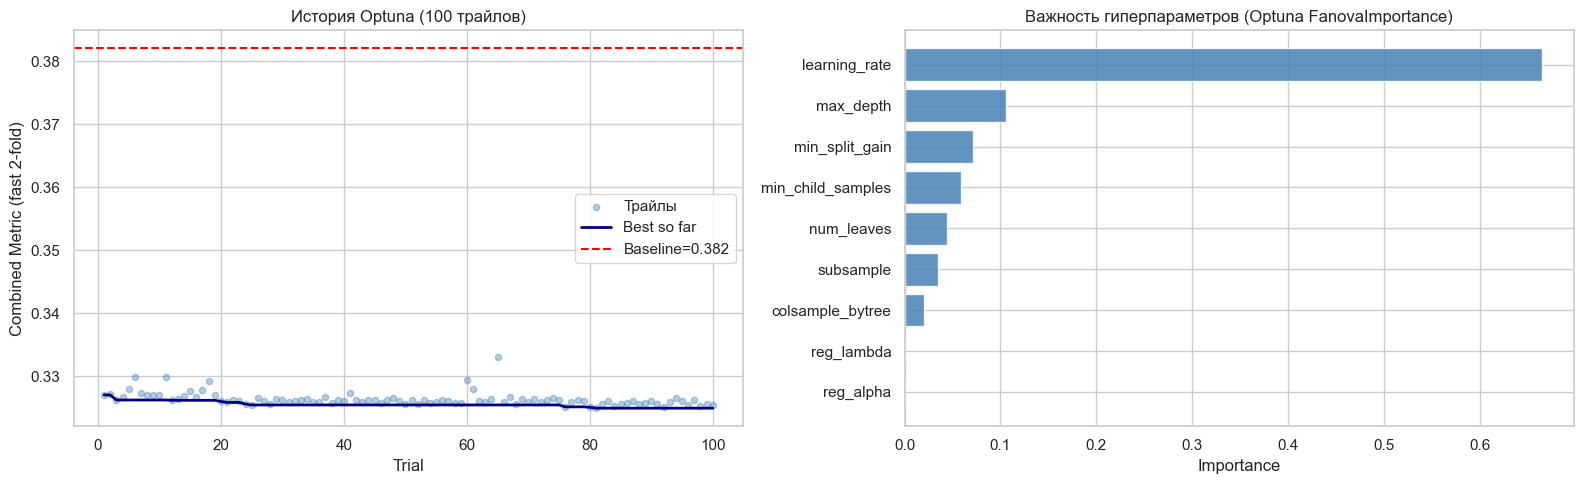


Лучшие гиперпараметры (Optuna):
----------------------------------------
  colsample_bytree          = 0.593317
  learning_rate             = 0.025210
  max_depth                 = 10
  min_child_samples         = 161
  min_split_gain            = 0.674336
  num_leaves                = 206
  reg_alpha                 = 0.023932
  reg_lambda                = 0.000001
  subsample                 = 0.839066

  (n_estimators определён early stopping внутри трайлов)


In [24]:
# История оптимизации
values      = [t.value for t in study.trials if t.value is not None]
best_so_far = pd.Series(values).cummin()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.scatter(range(1, len(values)+1), values, alpha=0.4, s=20, color='steelblue', label='Трайлы')
ax.plot(range(1, len(values)+1), best_so_far, '-', linewidth=2, color='navy', label='Best so far')
ax.axhline(BASELINE, color='red', linestyle='--', linewidth=1.5, label=f'Baseline={BASELINE}')
if EXP3_TOTAL:
    ax.axhline(EXP3_TOTAL, color='orange', linestyle=':', linewidth=1.5, label=f'Эксп 3={EXP3_TOTAL:.4f}')
ax.set_title(f'История Optuna ({N_TRIALS} трайлов)', fontsize=12)
ax.set_xlabel('Trial')
ax.set_ylabel('Combined Metric (fast 2-fold)')
ax.legend()

# Важность гиперпараметров
ax = axes[1]
try:
    param_imp = optuna.importance.get_param_importances(study)
    names, imps = zip(*sorted(param_imp.items(), key=lambda x: x[1]))
    ax.barh(names, imps, color='steelblue', alpha=0.85)
    ax.set_title('Важность гиперпараметров (Optuna FanovaImportance)', fontsize=12)
    ax.set_xlabel('Importance')
except Exception:
    ax.text(0.5, 0.5, 'Недостаточно трайлов\nдля анализа важности',
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

# Лучшие параметры
best_params = study.best_params
print('\nЛучшие гиперпараметры (Optuna):')
print('-' * 40)
for k, v in sorted(best_params.items()):
    if isinstance(v, float):
        print(f'  {k:<25} = {v:.6f}')
    else:
        print(f'  {k:<25} = {v}')
print(f'\n  (n_estimators определён early stopping внутри трайлов)')


In [ ]:
# Полный 3-fold CV с Optuna-параметрами
# Для финального CV используем ВЕСЬ трейн (не 28д окно) и subsample=FULL_SUBSAMPLE.
# n_estimators: ставим большой запас, early stopping найдёт оптимум на каждом фолде.

FINAL_PARAMS = dict(
    objective='regression_l1',
    n_estimators=5000,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
    **best_params,
)

fold_results    = []
last_model      = None
all_horizon_acc = {h: {'WAPE': [], 'Total': []} for h in HORIZONS}

print('Полный CV (3 субботних фолда, early stopping):')
print('=' * 60)

for fold_idx, cutoff in enumerate(VAL_CUTOFFS):
    t0 = time.time()
    print(f'\nФолд {fold_idx+1}/{len(VAL_CUTOFFS)}: cutoff = {cutoff}')

    train_cut   = train[train['timestamp'] <= cutoff].copy()
    route_stats = compute_route_stats(train_cut)

    print('  Вычисляю ref_features...', end=' ', flush=True)
    feat_df = compute_ref_features(train_cut, route_stats)
    print('готово')

    print('  Строю train_matrix...', end=' ', flush=True)
    train_mat = build_train_matrix(feat_df, train, subsample_n=FULL_SUBSAMPLE)
    print(f'готово — {len(train_mat):,} строк')

    # Early stopping: последняя неделя fold-а как eval set
    es_split = cutoff - pd.Timedelta(days=7)
    tr_mask  = train_mat['timestamp'] <= es_split
    X_tr     = train_mat.loc[tr_mask,  FEATURE_COLS]
    y_tr     = train_mat.loc[tr_mask,  'target'].values
    X_es     = train_mat.loc[~tr_mask, FEATURE_COLS]
    y_es     = train_mat.loc[~tr_mask, 'target'].values

    print('  Обучаю LightGBM (early stopping)...', end=' ', flush=True)
    model = lgb.LGBMRegressor(**FINAL_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_es, y_es)],
        callbacks=[
            lgb.early_stopping(ES_ROUNDS, verbose=False),
            lgb.log_evaluation(-1),
        ],
        categorical_feature=CAT_FEATURES,
    )
    n_best = model.best_iteration_
    print(f'готово  (best iter={n_best})')

    # Инференс
    infer_df = build_inference_matrix(feat_df, cutoff)
    infer_df = infer_df.sort_values(['horizon', 'route_id']).reset_index(drop=True)
    preds_raw = np.maximum(model.predict(infer_df[FEATURE_COLS]), 0)

    # Реальные значения
    actual_rows = []
    for h in HORIZONS:
        act = train[train['timestamp'] == cutoff + h * STEP][['route_id', 'target_1h']].copy()
        act['horizon'] = h
        actual_rows.append(act)
    actual_df = pd.concat(actual_rows).sort_values(['horizon', 'route_id']).reset_index(drop=True)
    y_val = actual_df['target_1h'].values

    ratio     = y_val.sum() / preds_raw.sum()
    preds_cal = preds_raw * ratio

    wape_v  = wape(y_val, preds_cal)
    rbias_v = relative_bias(y_val, preds_cal)
    total_v = wape_v + abs(rbias_v)

    horizon_metrics = []
    for h in HORIZONS:
        mask = (actual_df['horizon'] == h).values
        y_h, p_h = y_val[mask], preds_cal[mask]
        w_h, b_h = wape(y_h, p_h), relative_bias(y_h, p_h)
        t_h = w_h + abs(b_h)
        horizon_metrics.append({'horizon': h, 'WAPE': w_h, 'RBias': b_h, 'Total': t_h})
        all_horizon_acc[h]['WAPE'].append(w_h)
        all_horizon_acc[h]['Total'].append(t_h)

    elapsed = time.time() - t0
    print(f'  WAPE={wape_v:.4f}  |RBias|={abs(rbias_v):.4f}  Total={total_v:.4f}')
    print(f'  ratio={ratio:.4f}  best_iter={n_best}  время={elapsed:.1f}с')

    fold_results.append({
        'fold': fold_idx + 1, 'cutoff': str(cutoff.date()),
        'WAPE': wape_v, 'RBias': rbias_v, 'Total': total_v, 'ratio': ratio,
        'best_iter': n_best, 'horizon_metrics': horizon_metrics, 'elapsed': elapsed,
    })
    last_model = model

print(f'\n{"="*60}')
print('Валидация завершена.')


In [ ]:
# Сводная таблица
rows = [{'Фолд': r['fold'], 'Cutoff': r['cutoff'],
         'WAPE': r['WAPE'], '|RBias|': abs(r['RBias']),
         'Total': r['Total'], 'Ratio': r['ratio'],
         'Best iter': r['best_iter'], 'Время, с': round(r['elapsed'])}
        for r in fold_results]
res_df = pd.DataFrame(rows)
mean_row = res_df[['WAPE','|RBias|','Total','Ratio','Best iter','Время, с']].mean().to_dict()
mean_row.update({'Фолд': 'Среднее', 'Cutoff': ''})
res_df = pd.concat([res_df, pd.DataFrame([mean_row])], ignore_index=True)
print('Результаты кросс-валидации:')
print(res_df.to_string(index=False, float_format='{:.4f}'.format))

mean_total = float(res_df.loc[res_df['Фолд'] == 'Среднее', 'Total'].values[0])
print(f'\nБейзлайн: {BASELINE:.4f}')
if EXP3_TOTAL:
    print(f'Эксп 3 (default):  {EXP3_TOTAL:.4f}  (Δ={EXP3_TOTAL-BASELINE:+.4f})')
print(f'Эксп 6 (Optuna):   {mean_total:.4f}  (Δ={mean_total-BASELINE:+.4f})')
if EXP3_TOTAL:
    print(f'Улучшение vs Эксп 3: {mean_total - EXP3_TOTAL:+.4f}')

# Горизонтный анализ
h_wape  = [np.mean(all_horizon_acc[h]['WAPE'])  for h in HORIZONS]
h_total = [np.mean(all_horizon_acc[h]['Total']) for h in HORIZONS]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
x = np.arange(len(HORIZONS))
ax.bar(x - 0.2, h_total, 0.35, label='Total', color='steelblue', alpha=0.85)
ax.bar(x + 0.2, h_wape,  0.35, label='WAPE',  color='dodgerblue', alpha=0.85)
ax.axhline(BASELINE, color='red', linestyle='--', linewidth=1.5, label=f'Baseline={BASELINE}')
ax.set_xticks(x); ax.set_xticklabels([f'+{h*30}м' for h in HORIZONS])
ax.set_title('Метрика по горизонтам (Optuna-tuned)', fontsize=12)
ax.set_ylabel('Метрика'); ax.legend()

ax = axes[1]
for r in fold_results:
    totals = [hm['Total'] for hm in r['horizon_metrics']]
    ax.plot(HORIZONS, totals, 'o-', alpha=0.7, label=f"Фолд {r['fold']} ({r['cutoff']})")
ax.plot(HORIZONS, h_total, 'k^--', linewidth=2, markersize=8, label='Среднее')
ax.axhline(BASELINE, color='red', linestyle='--', linewidth=1.5)
ax.set_xticks(HORIZONS); ax.set_xticklabels([f'+{h*30}м' for h in HORIZONS])
ax.set_title('Total по горизонтам (все фолды)', fontsize=12)
ax.set_ylabel('WAPE + |RBias|'); ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
fi_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': last_model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
top = fi_df.head(25)
ax.barh(top['feature'][::-1], top['importance'][::-1], color='steelblue', alpha=0.85)
ax.set_title('Топ-25 признаков по важности (Optuna-tuned model)', fontsize=12)
ax.set_xlabel('Importance')
plt.setp(ax.get_yticklabels(), fontsize=9)

ax = axes[1]
status_names = [f for f in FEATURE_COLS if 'status' in f or 'pipeline' in f]
conv_fi = fi_df[fi_df['feature'].isin(status_names)].sort_values('importance', ascending=False)
colors  = ['tomato' if ('status_3' in n or 'pipeline' in n) else 'steelblue' for n in conv_fi['feature']]
ax.barh(conv_fi['feature'][::-1], conv_fi['importance'][::-1], color=colors[::-1], alpha=0.85)
ax.set_title('Важность конвейерных признаков\n(красный = status_3/pipeline)', fontsize=12)
ax.set_xlabel('Importance')
plt.setp(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.show()

zero_imp = fi_df[fi_df['importance'] == 0]['feature'].tolist()
print(f'Топ-10: {fi_df.head(10)["feature"].tolist()}')
if zero_imp:
    print(f'Нулевая важность: {zero_imp}')


In [ ]:
# Финальная модель: обучаем на ПОЛНОМ трейне
# n_estimators = среднее best_iteration из CV-фолдов * 1.1 (больше данных -> чуть больше деревьев)
mean_best_iter = int(np.mean([r['best_iter'] for r in fold_results]) * 1.1)
mean_ratio     = np.mean([r['ratio'] for r in fold_results])

print(f'Финальная модель: best_iter из CV = {[r["best_iter"] for r in fold_results]}')
print(f'Среднее * 1.1 = {mean_best_iter}  (используем как n_estimators)')
print(f'Калибровочный ratio = {mean_ratio:.4f}')

FINAL_PARAMS_FULL = dict(
    objective='regression_l1',
    n_estimators=mean_best_iter,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
    **best_params,
)

print('\nВычисляю route_stats и ref_features (полный train)...', end=' ', flush=True)
t0 = time.time()
route_stats_full = compute_route_stats(train)
feat_full = compute_ref_features(train, route_stats_full)
print(f'готово ({time.time()-t0:.1f}с)')

print('Строю train_matrix...', end=' ', flush=True)
train_mat_full = build_train_matrix(feat_full, train, subsample_n=FULL_SUBSAMPLE)
print(f'готово — {len(train_mat_full):,} строк')

print('Обучаю финальную модель...', end=' ', flush=True)
t1 = time.time()
model_final = lgb.LGBMRegressor(**FINAL_PARAMS_FULL)
model_final.fit(
    train_mat_full[FEATURE_COLS],
    train_mat_full['target'],
    categorical_feature=CAT_FEATURES,
)
print(f'готово ({time.time()-t1:.1f}с)')

# Тестовые прогнозы
infer_test = build_inference_matrix(feat_full, TEST_CUTOFF)
infer_test = infer_test.sort_values(['route_id', 'horizon']).reset_index(drop=True)

preds_raw = np.maximum(model_final.predict(infer_test[FEATURE_COLS]), 0)
preds_cal = preds_raw * mean_ratio

print(f'\nПрогнозы: min={preds_cal.min():.0f}  max={preds_cal.max():.0f}  mean={preds_cal.mean():.0f}')

# Submission
sub = infer_test[['route_id', 'tgt_ts']].copy()
sub['y_pred'] = preds_cal   # float, без округления
sub = sub.rename(columns={'tgt_ts': 'timestamp'})
test_ids = test[['id', 'route_id', 'timestamp']].copy()
sub = sub.merge(test_ids, on=['route_id', 'timestamp'], how='left')
sub = sub[['id', 'y_pred']].sort_values('id').reset_index(drop=True)

assert len(sub) == len(test)
assert sub['id'].notna().all()

out_path = '/Users/melikhovartem/Desktop/ИЗИ 200к/submission_exp06_lgbm_optuna.csv'
sub.to_csv(out_path, index=False)
print(f'\nSubmission сохранён: {out_path}')
print(sub.head(8).to_string(index=False))


In [ ]:
mean_total = np.mean([r['Total'] for r in fold_results])
mean_wape  = np.mean([r['WAPE']       for r in fold_results])
mean_rbias = np.mean([abs(r['RBias']) for r in fold_results])

print('=' * 65)
print('ИТОГОВЫЕ МЕТРИКИ — ЭКСПЕРИМЕНТ 6')
print('LightGBM + Optuna-тюнинг (150 трайлов, 2-fold fast objective)')
print('=' * 65)
print(f'\nВалидация: 3-fold rolling-origin (Oct 11 / Oct 18 / Oct 25)')
print(f'Архитектура: глобальная модель, horizon как фича, {len(FEATURE_COLS)} признаков')
print(f'Early stopping: {ES_ROUNDS} rounds (последняя неделя фолда как eval)')
print()

summary_df = pd.DataFrame({
    'Метрика': ['WAPE', '|Relative Bias|', 'Total (WAPE+|RBias|)'],
    'Значение': [f'{mean_wape:.4f}', f'{mean_rbias:.4f}', f'{mean_total:.4f}'],
})
print(summary_df.to_string(index=False))

print(f'\n{"-"*65}')
comparison = [
    {'Метод': 'Бейзлайн (среднее по маршруту)',    'Total': BASELINE,    'Delta': 0.0},
]
if EXP3_TOTAL:
    comparison.append({'Метод': 'Эксп 3 (LightGBM, default)', 'Total': EXP3_TOTAL, 'Delta': EXP3_TOTAL - BASELINE})
comparison.append({'Метод': 'Эксп 6 (LightGBM, Optuna)', 'Total': mean_total, 'Delta': mean_total - BASELINE})
cmp_df = pd.DataFrame(comparison)
print(cmp_df.to_string(index=False, float_format='{:.4f}'.format))

# Финальный bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
labels = [r['cutoff'] for r in fold_results]
totals = [r['Total']  for r in fold_results]
bars   = ax.bar(labels, totals, color='steelblue', alpha=0.85, width=0.5)
ax.axhline(mean_total, color='navy',  linewidth=2,   linestyle='-',  label=f'Среднее = {mean_total:.4f}')
ax.axhline(BASELINE,   color='red',   linewidth=1.5, linestyle='--', label=f'Baseline = {BASELINE}')
if EXP3_TOTAL:
    ax.axhline(EXP3_TOTAL, color='orange', linewidth=1.5, linestyle=':', label=f'Эксп 3 = {EXP3_TOTAL:.4f}')
for bar, v in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.4f}',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Total по фолдам (Optuna-tuned LightGBM)', fontsize=12)
ax.set_ylabel('WAPE + |RBias|'); ax.legend(); ax.set_ylim(0, max(totals) * 1.15)

ax = axes[1]
h_total = [np.mean(all_horizon_acc[h]['Total']) for h in HORIZONS]
h_wape  = [np.mean(all_horizon_acc[h]['WAPE'])  for h in HORIZONS]
ax.plot(HORIZONS, h_total, 'o-', color='steelblue',  linewidth=2, markersize=7, label='Total (Exp 6)')
ax.plot(HORIZONS, h_wape,  's--', color='dodgerblue', linewidth=1.5, markersize=6, label='WAPE (Exp 6)')
ax.axhline(BASELINE,   color='red',   linestyle='--', linewidth=1.5, label=f'Baseline={BASELINE}')
ax.axhline(mean_total, color='navy',  linestyle=':',  linewidth=1.5, label=f'Mean={mean_total:.4f}')
ax.set_xticks(HORIZONS); ax.set_xticklabels([f'+{h*30}м' for h in HORIZONS])
ax.set_title('Total по горизонтам', fontsize=12); ax.set_ylabel('Метрика'); ax.legend(fontsize=9)

plt.suptitle('Эксперимент 6: LightGBM + Optuna', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'\n{"="*65}')
print(f'  ИТОГ: Total = {mean_total:.4f}  (Δ baseline = {mean_total - BASELINE:+.4f})')
print(f'  Submission: submission_exp06_lgbm_optuna.csv')
print(f'{"="*65}')
